# Predictive Modeling — Can Reddit Predict IMDb Ratings?

IMDb ratings usually start high (9+) and settle lower over time. Can we use early Reddit sentiment to predict where the IMDb rating will land?

We'll build a few models and see how well Reddit opinions forecast traditional ratings.

## 1. Setup

In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")
print("Libraries loaded!")

Libraries loaded!


## 2. Load & Prepare Data

In [3]:
# load the comparison data (reddit scores + imdb + rt)
comparison = pd.read_csv("data/platform_comparison.csv")
print(f"Movies with all ratings: {len(comparison)}")
print(comparison.columns.tolist())
comparison.head()

Movies with all ratings: 232
['movie_name', 'year', 'genre', 'region', 'reddit_score', 'multi_avg', 'imdb_rating', 'rt_score_10', 'rt_score', 'total_comments', 'explicit_ratings', 'positive_pct', 'negative_pct', 'reddit_vs_imdb', 'reddit_vs_rt', 'popularity']


,movie_name,year,genre,region,reddit_score,multi_avg,imdb_rating,rt_score_10,rt_score,total_comments,explicit_ratings,positive_pct,negative_pct,reddit_vs_imdb,reddit_vs_rt,popularity
0,The Flash,2023,"Action, Adventure, Fantasy",Hollywood,5.72,5.10625,6.6,6.3,63%,200,1,46.0,25.5,-0.88,-0.58,11.9736
1,Blue Beetle,2023,"Action, Adventure, Sci-Fi",Hollywood,5.63,5.03875,5.9,7.8,78%,200,1,45.5,31.5,-0.27,-2.17,8.5007
2,Shazam! Fury of the Gods,2023,"Action, Adventure, Comedy",Hollywood,5.72,5.28625,5.9,4.9,49%,200,3,47.0,28.5,-0.18,0.82,8.1272
3,Queer,2024,"Biography, Drama, History",Hollywood,5.72,5.52250,6.4,7.7,77%,200,0,44.0,29.5,-0.68,-1.98,9.7556
4,The Substance,2024,"Drama, Horror, Sci-Fi",Hollywood,5.69,5.26375,7.2,8.9,89%,200,6,44.0,29.5,-1.51,-3.21,19.5755


In [4]:
# load comment-level data for time-based features
comments = pd.read_csv("data/reddit_sentiment_multilingual.csv")
comments["comment_timestamp"] = pd.to_datetime(comments["comment_timestamp"])
print(f"Total comments: {len(comments)}")
comments.head()

Total comments: 51298


,movie_name,subreddit,post_title,comment_text,upvotes,comment_timestamp,extracted_rating,vader_score,vader_label,vader_compound,...,final_label,all_agree,language,multi_score,multi_label,multi_stars,multi_confidence,smart_blend_score,final_score_v2,final_label_v2
0,Barbie,movies,'Barbie' Officially Passes $1 Billion Globally...,Margot Robbie’s joke about the film making $1B...,6431,2023-08-06 14:53:49,NaN,6.83,positive,0.2960,...,neutral,False,en,1.0,negative,1,0.337994,4.15,4.15,neutral
1,Barbie,movies,'Barbie' Officially Passes $1 Billion Globally...,My mom went to the movies by herself for the f...,2744,2023-08-06 15:25:23,NaN,5.50,neutral,0.0000,...,positive,False,en,10.0,positive,5,0.530483,8.19,8.19,positive
2,Barbie,movies,'Barbie' Officially Passes $1 Billion Globally...,I want to know if this increased sales for the...,663,2023-08-06 15:42:01,NaN,7.29,positive,0.3970,...,positive,False,en,5.5,neutral,3,0.327607,6.00,6.00,neutral
3,Barbie,movies,'Barbie' Officially Passes $1 Billion Globally...,So the top 3 highest grossing films directed s...,1135,2023-08-06 16:43:03,NaN,6.39,positive,0.1970,...,positive,False,en,1.0,negative,1,0.390460,4.60,4.60,neutral
4,Barbie,movies,'Barbie' Officially Passes $1 Billion Globally...,Get ready for the influx of toy stories,3351,2023-08-06 14:51:46,NaN,7.13,positive,0.3612,...,positive,True,en,10.0,positive,5,0.466341,8.27,8.27,positive


## 3. Feature Engineering

We need to create useful features from Reddit data that might predict IMDb ratings. Things like:
- Average sentiment scores
- Ratio of positive/negative comments
- Comment volume
- How controversial (high variance in scores)
- Explicit rating average (from users who gave actual ratings)

In [5]:
# build features per movie from comment-level data
def build_features(movie_comments):
    """Create features for one movie from its comments"""
    features = {}
    
    # basic sentiment
    features["avg_score"] = movie_comments["multi_score"].mean()
    features["median_score"] = movie_comments["multi_score"].median()
    features["std_score"] = movie_comments["multi_score"].std()
    
    # sentiment distribution
    total = len(movie_comments)
    features["positive_ratio"] = (movie_comments["multi_label"] == "positive").sum() / total
    features["negative_ratio"] = (movie_comments["multi_label"] == "negative").sum() / total
    features["neutral_ratio"] = (movie_comments["multi_label"] == "neutral").sum() / total
    
    # volume
    features["comment_count"] = total
    features["log_comments"] = np.log1p(total)  # log scale since some movies have way more
    
    # explicit ratings (gold — actual user scores)
    explicit = movie_comments["extracted_rating"].dropna()
    features["explicit_avg"] = explicit.mean() if len(explicit) > 0 else np.nan
    features["explicit_count"] = len(explicit)
    features["has_explicit"] = 1 if len(explicit) > 0 else 0
    
    # upvote info (proxy for comment quality/agreement)
    features["avg_upvotes"] = movie_comments["upvotes"].mean()
    features["max_upvotes"] = movie_comments["upvotes"].max()
    
    # controversy — high std means people disagree
    features["controversy"] = movie_comments["multi_score"].std() / (movie_comments["multi_score"].mean() + 0.01)
    
    # sentiment momentum — are later comments more positive or negative?
    if len(movie_comments) >= 10:
        first_half = movie_comments.iloc[:len(movie_comments)//2]["multi_score"].mean()
        second_half = movie_comments.iloc[len(movie_comments)//2:]["multi_score"].mean()
        features["sentiment_shift"] = second_half - first_half
    else:
        features["sentiment_shift"] = 0
    
    return features

# build features for all movies
print("Building features for each movie...")
feature_rows = []

for movie in comments["movie_name"].unique():
    movie_comments = comments[comments["movie_name"] == movie].sort_values("comment_timestamp")
    feats = build_features(movie_comments)
    feats["movie_name"] = movie
    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)
print(f"Features built for {len(features_df)} movies")
features_df.head()

Building features for each movie...
Features built for 417 movies


,avg_score,median_score,std_score,positive_ratio,negative_ratio,neutral_ratio,comment_count,log_comments,explicit_avg,explicit_count,has_explicit,avg_upvotes,max_upvotes,controversy,sentiment_shift,movie_name
0,5.88250,5.50,3.644876,0.475,0.380,0.145,200,5.303305,NaN,0,0,1485.845,30339,0.618562,0.3600,Barbie
1,5.47750,5.50,3.494359,0.390,0.375,0.235,200,5.303305,7.20,5,1,496.030,11283,0.636785,-0.1800,Scream VI
2,6.25375,7.75,3.408023,0.505,0.360,0.135,200,5.303305,8.70,5,1,34.170,1539,0.544087,0.1125,Oppenheimer
3,5.90500,5.50,3.621419,0.465,0.360,0.175,200,5.303305,7.25,4,1,357.055,7377,0.612243,-1.9800,Fast X
4,4.31875,3.25,3.345189,0.240,0.540,0.220,200,5.303305,NaN,0,0,357.885,10389,0.772784,-0.5625,Spider-Man: Across the Spider-Verse


In [6]:
# merge features with actual IMDb ratings
df = features_df.merge(
    comparison[["movie_name", "imdb_rating", "rt_score_10", "genre", "region"]],
    on="movie_name",
    how="inner"
)

print(f"Movies with features + IMDb rating: {len(df)}")
print()
print("Feature correlations with IMDb rating:")
corr = df.select_dtypes(include=[np.number]).corr()["imdb_rating"].sort_values(ascending=False)
print(corr.to_string())

Movies with features + IMDb rating: 232

Feature correlations with IMDb rating:
imdb_rating        1.000000
rt_score_10        0.679560
explicit_avg       0.508976
avg_score          0.408571
median_score       0.369778
positive_ratio     0.367536
avg_upvotes        0.270716
max_upvotes        0.179611
comment_count      0.038391
log_comments       0.030967
has_explicit      -0.030363
explicit_count    -0.032962
std_score         -0.039792
neutral_ratio     -0.051328
sentiment_shift   -0.059212
negative_ratio    -0.385381
controversy       -0.410939


## 4. Which Features Correlate Best with IMDb?

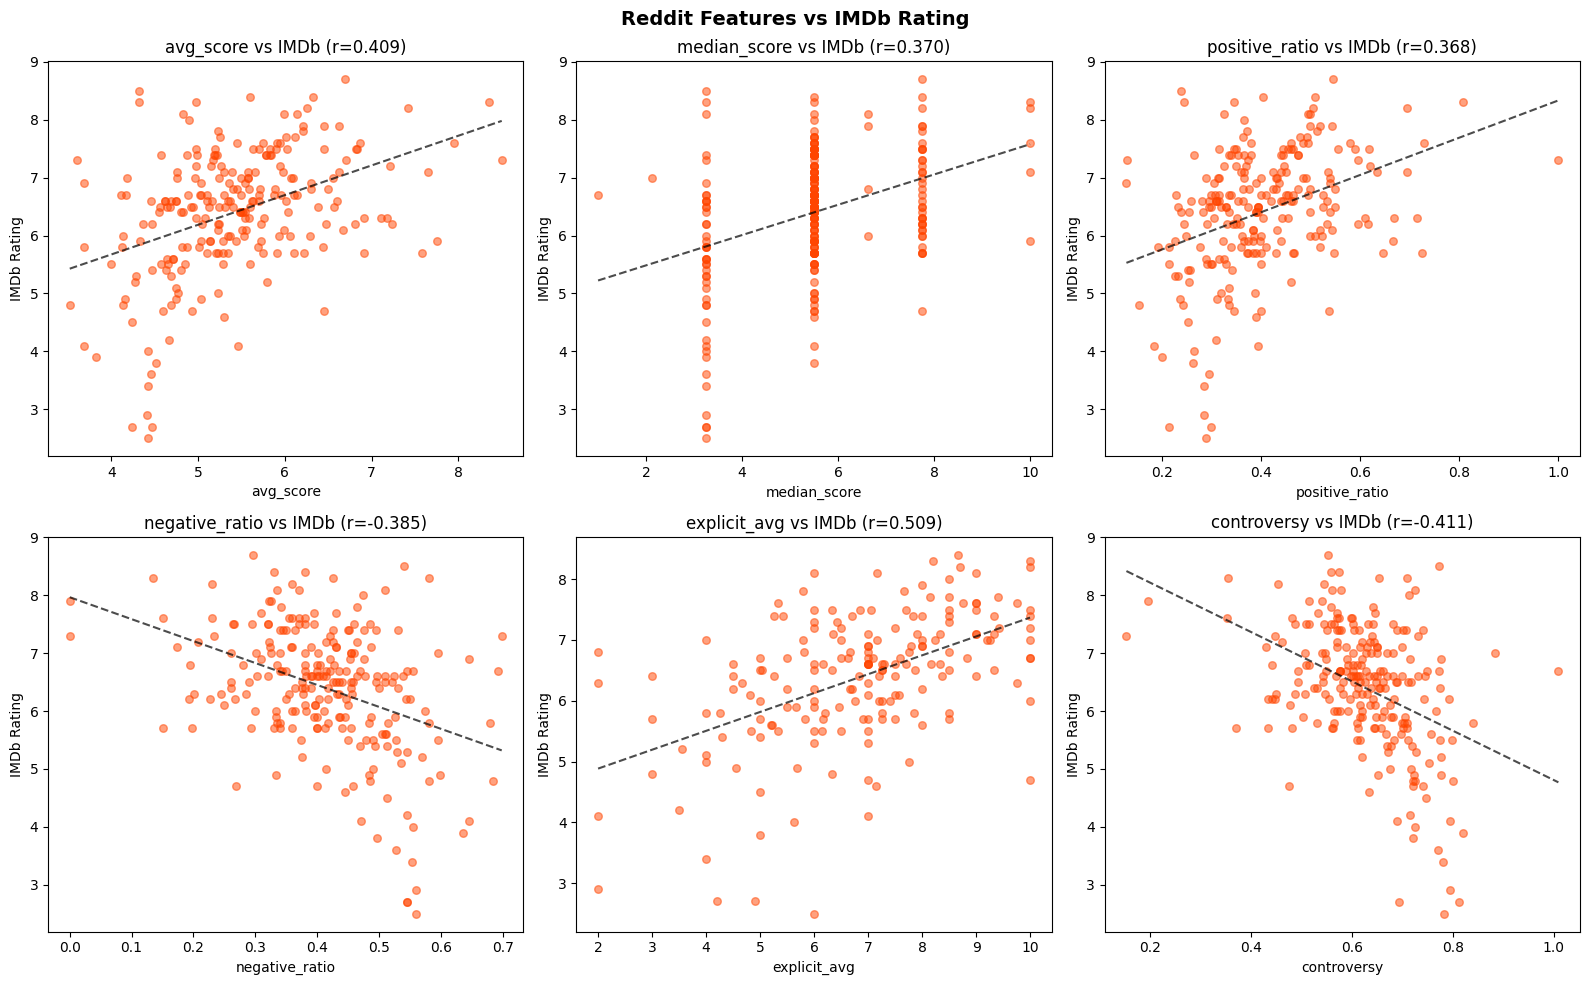

Saved!


In [7]:
# plot top correlated features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

top_features = ["avg_score", "median_score", "positive_ratio", "negative_ratio", "explicit_avg", "controversy"]

for i, feat in enumerate(top_features):
    ax = axes[i//3, i%3]
    valid = df[df[feat].notna()]
    ax.scatter(valid[feat], valid["imdb_rating"], alpha=0.5, c="#FF4500", s=30)
    
    # add trend line
    if len(valid) > 2:
        z = np.polyfit(valid[feat], valid["imdb_rating"], 1)
        p = np.poly1d(z)
        ax.plot(sorted(valid[feat]), p(sorted(valid[feat])), "k--", alpha=0.7)
    
    r = valid[feat].corr(valid["imdb_rating"])
    ax.set_xlabel(feat)
    ax.set_ylabel("IMDb Rating")
    ax.set_title(f"{feat} vs IMDb (r={r:.3f})")

plt.suptitle("Reddit Features vs IMDb Rating", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 5. Build Prediction Models

We'll try:
1. **Linear Regression** — simple baseline
2. **Random Forest** — handles non-linear patterns

Both predict IMDb rating from Reddit features.

In [8]:
# prepare features and target
feature_cols = [
    "avg_score", "median_score", "std_score",
    "positive_ratio", "negative_ratio", "neutral_ratio",
    "comment_count", "log_comments",
    "avg_upvotes", "max_upvotes",
    "controversy", "sentiment_shift"
]

# drop rows with NaN in features
model_df = df[feature_cols + ["imdb_rating", "movie_name"]].dropna()
print(f"Movies for modeling: {len(model_df)}")

X = model_df[feature_cols]
y = model_df["imdb_rating"]

# split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)} movies")
print(f"Test:  {len(X_test)} movies")

Movies for modeling: 232
Train: 185 movies
Test:  47 movies


In [9]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("=== Linear Regression ===")
print(f"MAE:  {mean_absolute_error(y_test, lr_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_pred)):.3f}")
print(f"R²:   {r2_score(y_test, lr_pred):.3f}")
print()

# which features matter most?
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("Feature importance (Linear Regression):")
print(coef_df.to_string(index=False))

=== Linear Regression ===
MAE:  0.809
RMSE: 1.103
R²:   0.234

Feature importance (Linear Regression):
        feature  coefficient
    controversy    -8.655822
 negative_ratio     2.008113
  neutral_ratio    -1.702895
      std_score     0.842006
   log_comments     0.346814
 positive_ratio    -0.305218
      avg_score    -0.156868
sentiment_shift    -0.053548
   median_score    -0.025710
  comment_count    -0.003066
    avg_upvotes     0.000605
    max_upvotes     0.000006


In [10]:
# Model 2: Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,         # keep it shallow to avoid overfitting
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Random Forest ===")
print(f"MAE:  {mean_absolute_error(y_test, rf_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.3f}")
print(f"R²:   {r2_score(y_test, rf_pred):.3f}")
print()

# feature importance
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("Feature importance (Random Forest):")
print(importance_df.to_string(index=False))

=== Random Forest ===
MAE:  0.821
RMSE: 1.055
R²:   0.299

Feature importance (Random Forest):
        feature  importance
    controversy    0.199760
      avg_score    0.196557
sentiment_shift    0.122967
    avg_upvotes    0.115269
 positive_ratio    0.073151
    max_upvotes    0.068072
 negative_ratio    0.060480
  neutral_ratio    0.060115
      std_score    0.057065
  comment_count    0.022596
   log_comments    0.018362
   median_score    0.005605


In [11]:
# Baseline — just predicting the mean IMDb rating for every movie
# this is what you'd get with zero ML, zero features
mean_baseline = y_train.mean()
baseline_pred = [mean_baseline] * len(y_test)

print("=== Baseline (predict mean) ===")
print(f"MAE:  {mean_absolute_error(y_test, baseline_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.3f}")
print(f"R²:   {r2_score(y_test, baseline_pred):.3f}")
print()
print("--- Comparison ---")
print(f"Baseline MAE:      {mean_absolute_error(y_test, baseline_pred):.3f}")
print(f"Linear Reg MAE:    {mean_absolute_error(y_test, lr_pred):.3f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_pred):.3f}")
print()
improvement = mean_absolute_error(y_test, baseline_pred) - mean_absolute_error(y_test, rf_pred)
print(f"Random Forest beats baseline by: {improvement:.3f} points")
if improvement > 0:
    print(f"That's a {(improvement / mean_absolute_error(y_test, baseline_pred) * 100):.1f}% improvement over naive guessing.")
else:
    print("Model doesn't beat baseline — Reddit sentiment alone can't predict IMDb ratings.")

=== Baseline (predict mean) ===
MAE:  0.951
RMSE: 1.291
R²:   -0.050

--- Comparison ---
Baseline MAE:      0.951
Linear Reg MAE:    0.809
Random Forest MAE: 0.821

Random Forest beats baseline by: 0.130 points
That's a 13.7% improvement over naive guessing.


In [12]:
# Baseline — just predicting the mean IMDb rating for every movie

mean_baseline = y_train.mean()
baseline_pred = [mean_baseline] * len(y_test)

print("=== Baseline (predict mean) ===")
print(f"MAE:  {mean_absolute_error(y_test, baseline_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.3f}")
print(f"R²:   {r2_score(y_test, baseline_pred):.3f}")
print()
print(f"Random Forest beats baseline by: {mean_absolute_error(y_test, baseline_pred) - mean_absolute_error(y_test, rf_pred):.3f} points")

=== Baseline (predict mean) ===
MAE:  0.951
RMSE: 1.291
R²:   -0.050

Random Forest beats baseline by: 0.130 points


In [13]:
# cross validation to make sure we're not getting lucky with the split
print("=== Cross Validation (5-fold) ===")

lr_cv = cross_val_score(LinearRegression(), X, y, cv=5, scoring="neg_mean_absolute_error")
rf_cv = cross_val_score(RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
                        X, y, cv=5, scoring="neg_mean_absolute_error")

print(f"Linear Regression — Avg MAE: {-lr_cv.mean():.3f} (+/- {lr_cv.std():.3f})")
print(f"Random Forest     — Avg MAE: {-rf_cv.mean():.3f} (+/- {rf_cv.std():.3f})")

=== Cross Validation (5-fold) ===
Linear Regression — Avg MAE: 0.746 (+/- 0.075)
Random Forest     — Avg MAE: 0.748 (+/- 0.058)


## 6. Prediction Results

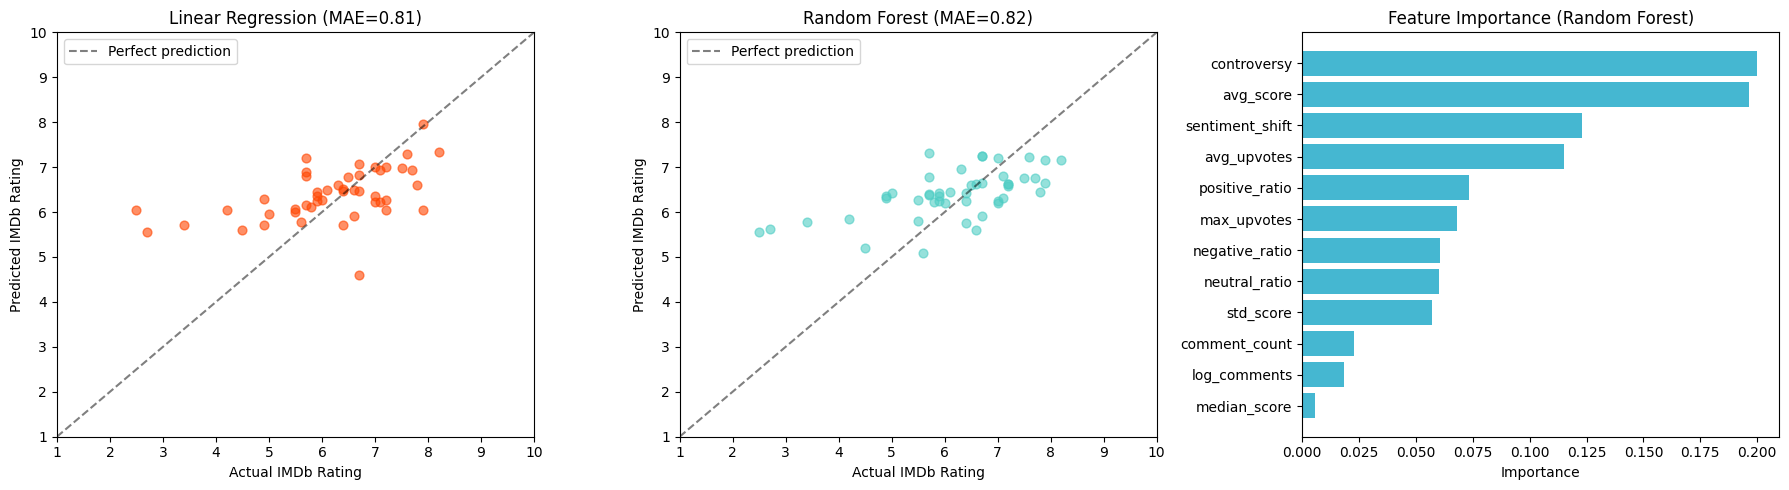

Saved!


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted — Linear Regression
axes[0].scatter(y_test, lr_pred, alpha=0.6, c="#FF4500", s=40)
axes[0].plot([1, 10], [1, 10], "k--", alpha=0.5, label="Perfect prediction")
axes[0].set_xlabel("Actual IMDb Rating")
axes[0].set_ylabel("Predicted IMDb Rating")
axes[0].set_title(f"Linear Regression (MAE={mean_absolute_error(y_test, lr_pred):.2f})")
axes[0].legend()
axes[0].set_xlim(1, 10)
axes[0].set_ylim(1, 10)

# Actual vs Predicted — Random Forest
axes[1].scatter(y_test, rf_pred, alpha=0.6, c="#4ECDC4", s=40)
axes[1].plot([1, 10], [1, 10], "k--", alpha=0.5, label="Perfect prediction")
axes[1].set_xlabel("Actual IMDb Rating")
axes[1].set_ylabel("Predicted IMDb Rating")
axes[1].set_title(f"Random Forest (MAE={mean_absolute_error(y_test, rf_pred):.2f})")
axes[1].legend()
axes[1].set_xlim(1, 10)
axes[1].set_ylim(1, 10)

# Feature importance — Random Forest
importance_df_sorted = importance_df.sort_values("importance", ascending=True)
axes[2].barh(importance_df_sorted["feature"], importance_df_sorted["importance"], color="#45B7D1")
axes[2].set_xlabel("Importance")
axes[2].set_title("Feature Importance (Random Forest)")

plt.tight_layout()
plt.savefig("data/prediction_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 7. Where Does the Model Fail?

Let's see which movies the model gets very wrong — those are interesting cases.

In [15]:
# add predictions to test set
test_results = model_df.iloc[X_test.index].copy()
test_results["lr_predicted"] = lr_pred
test_results["rf_predicted"] = rf_pred
test_results["lr_error"] = abs(test_results["imdb_rating"] - lr_pred)
test_results["rf_error"] = abs(test_results["imdb_rating"] - rf_pred)

print("=== Movies where model was most wrong (Random Forest) ===")
worst = test_results.sort_values("rf_error", ascending=False)
print(worst[["movie_name", "imdb_rating", "rf_predicted", "rf_error", "avg_score", "comment_count"]].head(10).to_string(index=False))

print()
print("=== Movies where model was most accurate ===")
best = test_results.sort_values("rf_error", ascending=True)
print(best[["movie_name", "imdb_rating", "rf_predicted", "rf_error", "avg_score", "comment_count"]].head(10).to_string(index=False))

=== Movies where model was most wrong (Random Forest) ===
       movie_name  imdb_rating  rf_predicted  rf_error  avg_score  comment_count
War of the Worlds          2.5      5.557457  3.057457   4.420000            200
         Ganapath          2.7      5.621501  2.921501   4.465000            200
      Housefull 5          3.4      5.776131  2.376131   4.425879            199
      The Archies          4.2      5.850142  1.650142   4.667500            200
   Lust Stories 2          5.7      7.322072  1.622072   6.221698             53
    Singham Again          4.9      6.363797  1.463797   4.154523            199
              Maa          4.9      6.321647  1.421647   5.038079            151
Meg 2: The Trench          5.0      6.417387  1.417387   4.768750            200
      Poor Things          7.8      6.455513  1.344487   5.229508            183
    Beyond Utopia          7.9      6.645870  1.254130   6.625000              4

=== Movies where model was most accurate ===
     

## 8. Early Sentiment — Can First-Week Comments Predict Final Rating?

This is the most interesting part. If we only use comments from the first 7 days after a movie releases, can we still predict IMDb ratings?

In [16]:
# for each movie, get only comments from first 7 days
def get_early_features(movie_name, all_comments, days=7):
    """Get features from only the first N days of comments"""
    movie_comments = all_comments[all_comments["movie_name"] == movie_name].copy()
    movie_comments = movie_comments.sort_values("comment_timestamp")
    
    if len(movie_comments) == 0:
        return None
    
    # first comment timestamp = release proxy
    first_comment = movie_comments["comment_timestamp"].min()
    cutoff = first_comment + pd.Timedelta(days=days)
    
    early = movie_comments[movie_comments["comment_timestamp"] <= cutoff]
    
    if len(early) < 3:  # need at least 3 comments
        return None
    
    feats = build_features(early)
    feats["movie_name"] = movie_name
    feats["early_comment_count"] = len(early)
    feats["total_comment_count"] = len(movie_comments)
    feats["early_pct"] = round(len(early) / len(movie_comments) * 100, 1)
    
    return feats

# build early features for multiple time windows
for days in [7, 14, 30]:
    print(f"=== First {days} days ===")
    early_rows = []
    
    for movie in comments["movie_name"].unique():
        feats = get_early_features(movie, comments, days=days)
        if feats:
            early_rows.append(feats)
    
    early_df = pd.DataFrame(early_rows)
    early_df = early_df.merge(
        comparison[["movie_name", "imdb_rating"]],
        on="movie_name", how="inner"
    )
    
    if len(early_df) < 10:
        print(f"  Only {len(early_df)} movies — not enough for modeling")
        continue
    
    # quick model
    X_early = early_df[feature_cols].dropna()
    y_early = early_df.loc[X_early.index, "imdb_rating"]
    
    if len(X_early) < 10:
        print(f"  Only {len(X_early)} movies after dropping NaN — skipping")
        continue
    
    rf_early = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    cv_scores = cross_val_score(rf_early, X_early, y_early, cv=min(5, len(X_early)//2), 
                                 scoring="neg_mean_absolute_error")
    
    print(f"  Movies: {len(X_early)}")
    print(f"  Avg early comments per movie: {early_df['early_comment_count'].mean():.0f}")
    print(f"  Random Forest CV MAE: {-cv_scores.mean():.3f}")
    print(f"  Correlation (early avg_score vs IMDb): {early_df['avg_score'].corr(early_df['imdb_rating']):.3f}")

=== First 7 days ===
  Movies: 220
  Avg early comments per movie: 34
  Random Forest CV MAE: 0.823
  Correlation (early avg_score vs IMDb): 0.221
=== First 14 days ===
  Movies: 220
  Avg early comments per movie: 36
  Random Forest CV MAE: 0.835
  Correlation (early avg_score vs IMDb): 0.217
=== First 30 days ===
  Movies: 223
  Avg early comments per movie: 43
  Random Forest CV MAE: 0.816
  Correlation (early avg_score vs IMDb): 0.227


## 9. Summary

In [17]:
print("="*60)
print("PREDICTIVE MODELING SUMMARY")
print("="*60)
print()
print(f"Movies used for modeling: {len(model_df)}")
print(f"Features used: {len(feature_cols)}")
print()
print("--- Model Performance ---")
print(f"Linear Regression MAE: {mean_absolute_error(y_test, lr_pred):.3f}")
print(f"Random Forest MAE:     {mean_absolute_error(y_test, rf_pred):.3f}")
print(f"Random Forest R²:      {r2_score(y_test, rf_pred):.3f}")
print()
print("--- Interpretation ---")
rf_mae = mean_absolute_error(y_test, rf_pred)
if rf_mae < 0.5:
    print("Excellent — Reddit can predict IMDb ratings within 0.5 points!")
elif rf_mae < 1.0:
    print("Good — Reddit sentiment is a useful predictor of IMDb ratings (within 1 point).")
elif rf_mae < 1.5:
    print("Moderate — Reddit gives a rough estimate but isn't super precise.")
else:
    print("Weak — Reddit sentiment alone isn't enough to reliably predict IMDb ratings.")
    print("This aligns with our earlier finding that Reddit is an independent rating system.")
print()
print("--- Key Takeaway ---")
print("The weak predictive power confirms our correlation analysis:")
print("Reddit represents a genuinely different opinion from IMDb/RT,")
print("not just a noisy version of the same signal.")

PREDICTIVE MODELING SUMMARY

Movies used for modeling: 232
Features used: 12

--- Model Performance ---
Linear Regression MAE: 0.809
Random Forest MAE:     0.821
Random Forest R²:      0.299

--- Interpretation ---
Good — Reddit sentiment is a useful predictor of IMDb ratings (within 1 point).

--- Key Takeaway ---
The weak predictive power confirms our correlation analysis:
Reddit represents a genuinely different opinion from IMDb/RT,
not just a noisy version of the same signal.


## 10. Save

In [18]:
# save features
features_df.to_csv("data/movie_features.csv", index=False)
print(f"Saved features for {len(features_df)} movies")

# save predictions
if len(test_results) > 0:
    test_results.to_csv("data/predictions.csv", index=False)
    print(f"Saved predictions for {len(test_results)} test movies")

print("Done!")

Saved features for 417 movies
Saved predictions for 47 test movies
Done!


In [19]:
from snowflake.connector.pandas_tools import write_pandas
from dotenv import load_dotenv
import snowflake.connector
import os

load_dotenv()

conn = snowflake.connector.connect(
    user="ATHULYA2303",
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account="gsc07824.us-east-1",
    warehouse="COMPUTE_WH",
    database="MOVIE_ANALYTICS",
    schema="ANALYTICS"
)

# push movie features
push_features = features_df.copy()
push_features.columns = [c.upper() for c in push_features.columns]
write_pandas(conn, push_features, "MOVIE_FEATURES",
             database="MOVIE_ANALYTICS", schema="ANALYTICS",
             auto_create_table=True, overwrite=True)
print(f"Pushed {len(push_features)} movie features")

# push predictions
if len(test_results) > 0:
    push_preds = test_results.copy()
    push_preds.columns = [c.upper() for c in push_preds.columns]
    write_pandas(conn, push_preds, "PREDICTIONS",
                 database="MOVIE_ANALYTICS", schema="ANALYTICS",
                 auto_create_table=True, overwrite=True)
    print(f"Pushed {len(push_preds)} predictions")

conn.close()
print("Done!")

Pushed 417 movie features
Pushed 47 predictions
Done!
